In [59]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor,
    VotingClassifier,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

In [ ]:
import struct
print(struct.calcsize("P") * 8)

64


In [2]:
hotel = pd.read_csv('booking.csv')

In [3]:
hotel['count'] = 1

In [4]:
hotel.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status,count
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled,1
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled,1
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled,1
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled,1
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled,1


In [5]:
hotel.columns

Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'market segment type',
       'repeated', 'P-C', 'P-not-C', 'average price', 'special requests',
       'date of reservation', 'booking status', 'count'],
      dtype='str')

In [6]:
hotel.info()

<class 'pandas.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  str    
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  str    
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  str    
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  str    
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  special requests 

In [7]:
hotel.isna().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
count                       0
dtype: int64

<Axes: >

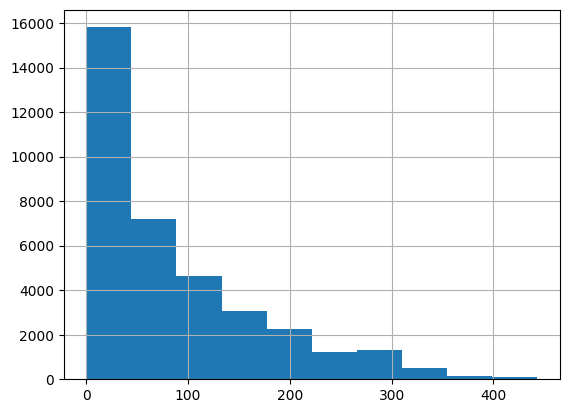

In [8]:
hotel['lead time'].hist()

In [9]:
hotel['date of reservation'] = pd.to_datetime(
    hotel['date of reservation'],
    errors='coerce'
)

In [10]:
hotel.dropna(subset=['date of reservation'])

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status,count
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,2015-10-02,Not_Canceled,1
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,2018-11-06,Not_Canceled,1
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2018-02-28,Canceled,1
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,2017-05-20,Canceled,1
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,2018-04-11,Canceled,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36280,INN36282,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,Online,0,0,0,115.00,1,2018-09-13,Canceled,1
36281,INN36283,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,Online,0,0,0,107.55,1,2017-10-15,Not_Canceled,1
36282,INN36284,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,Online,0,0,0,105.61,1,2018-12-26,Not_Canceled,1
36283,INN36285,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,Offline,0,0,0,96.90,1,2018-07-06,Not_Canceled,1


In [11]:
hotel = hotel.dropna(subset=['date of reservation'])

In [12]:
hotel['month'] = hotel['date of reservation'].dt.month
hotel['month_name'] = hotel['date of reservation'].dt.month_name()
hotel['year'] = hotel['date of reservation'].dt.year
hotel['day_name'] = hotel['date of reservation'].dt.day_name()
hotel['day'] = hotel['date of reservation'].dt.day

In [13]:
condition = hotel['year'] <= 2016
hotel = hotel[~condition]


In [14]:
hotel.head(10)

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,...,average price,special requests,date of reservation,booking status,count,month,month_name,year,day_name,day
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,...,106.68,1,2018-11-06,Not_Canceled,1,11,November,2018,Tuesday,6
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,...,50.00,0,2018-02-28,Canceled,1,2,February,2018,Wednesday,28
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,...,100.00,1,2017-05-20,Canceled,1,5,May,2017,Saturday,20
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,...,77.00,0,2018-04-11,Canceled,1,4,April,2018,Wednesday,11
6,INN00007,1,1,1,4,Meal Plan 1,0,Room_Type 1,34,Online,...,107.55,1,2017-10-15,Not_Canceled,1,10,October,2017,Sunday,15
7,INN00008,3,0,1,3,Meal Plan 1,0,Room_Type 4,83,Online,...,105.61,1,2018-12-26,Not_Canceled,1,12,December,2018,Wednesday,26
8,INN00009,1,1,0,4,Meal Plan 1,0,Room_Type 1,121,Offline,...,96.90,1,2018-07-06,Not_Canceled,1,7,July,2018,Friday,6
9,INN00010,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,Online,...,133.44,3,2018-10-18,Not_Canceled,1,10,October,2018,Thursday,18
10,INN00011,1,0,1,0,Not Selected,0,Room_Type 1,0,Online,...,85.03,0,2018-09-11,Not_Canceled,1,9,September,2018,Tuesday,11
11,INN00012,1,0,2,1,Meal Plan 1,0,Room_Type 4,35,Online,...,140.40,1,2018-04-30,Not_Canceled,1,4,April,2018,Monday,30


In [15]:
hotel['Total People'] = hotel['number of adults'] + hotel['number of children']

In [16]:
hotel['clean_reservation_date'] = pd.to_datetime(
    hotel[['year', 'month', 'day']]
)

In [17]:
hotel.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,...,date of reservation,booking status,count,month,month_name,year,day_name,day,Total People,clean_reservation_date
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,...,2018-11-06,Not_Canceled,1,11,November,2018,Tuesday,6,1,2018-11-06
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,...,2018-02-28,Canceled,1,2,February,2018,Wednesday,28,3,2018-02-28
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,...,2017-05-20,Canceled,1,5,May,2017,Saturday,20,1,2017-05-20
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,...,2018-04-11,Canceled,1,4,April,2018,Wednesday,11,1,2018-04-11
6,INN00007,1,1,1,4,Meal Plan 1,0,Room_Type 1,34,Online,...,2017-10-15,Not_Canceled,1,10,October,2017,Sunday,15,2,2017-10-15


In [18]:
hotel['arrival_date'] = hotel['clean_reservation_date'] + pd.to_timedelta(hotel['lead time'], unit='D')

In [19]:
hotel[['arrival_date','clean_reservation_date','lead time']]

,arrival_date,clean_reservation_date,lead time
1,2018-11-11,2018-11-06,5
2,2018-03-01,2018-02-28,1
3,2017-12-17,2017-05-20,211
4,2018-05-29,2018-04-11,48
6,2017-11-18,2017-10-15,34
...,...,...,...
36280,2019-08-25,2018-09-13,346
36281,2017-11-18,2017-10-15,34
36282,2019-03-19,2018-12-26,83
36283,2018-11-04,2018-07-06,121


# The year which had the most booking

Text(0.5, 1.0, 'Trend of years with the number of bookings')

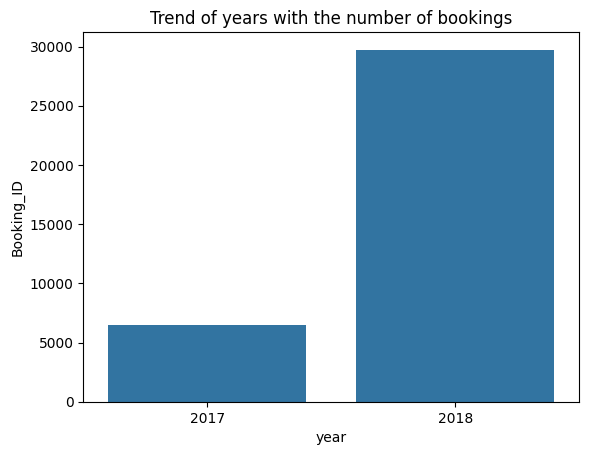

In [20]:
newDf = hotel.groupby("year")['Booking_ID'].count().reset_index()
sns.barplot(
    x='year',
    y='Booking_ID',
    data=newDf
)
plt.title("Trend of years with the number of bookings")

<Axes: xlabel='month', ylabel='count'>

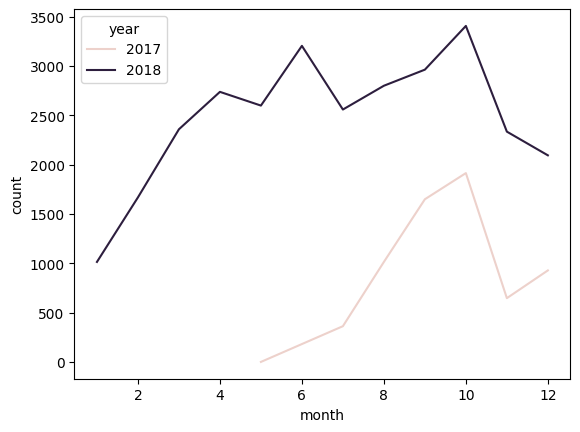

In [21]:
newDf = hotel.groupby(["month",'year'])['count'].count().reset_index()
sns.lineplot(
    x='month',
    y='count',
    data=newDf,
    hue='year'   
)

# As we can see October has the most booking followed by June

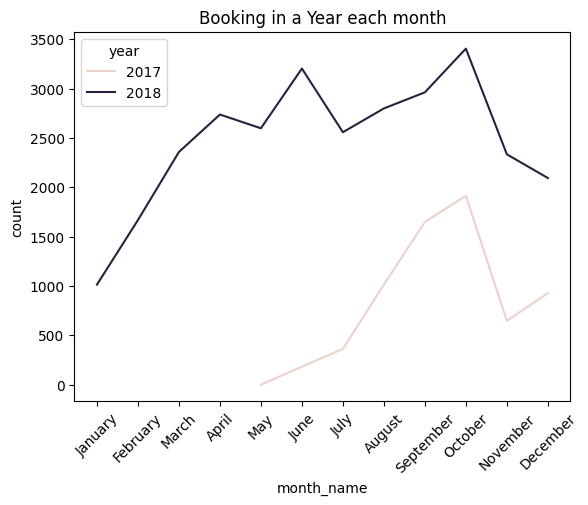

In [22]:
newDf = hotel.groupby(["month",'year','month_name'])['count'].count().reset_index()

sns.lineplot(
    x='month_name',
    y='count',
    data=newDf,
    hue='year'   
)

plt.xticks(rotation=45)
plt.title("Booking in a Year each month")
plt.show()

# Number of people vs the Avg price

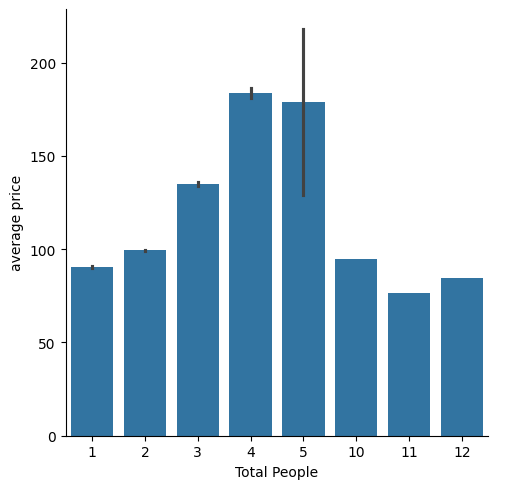

In [23]:
# sns.scatterplot(
#     x='Total People',
#     y='average price',
#     data=hotel,
# )

sns.catplot(
    x='Total People',
    y='average price',
    data=hotel,
    kind='bar'
)

# Booking Status

<Axes: xlabel='booking status', ylabel='count'>

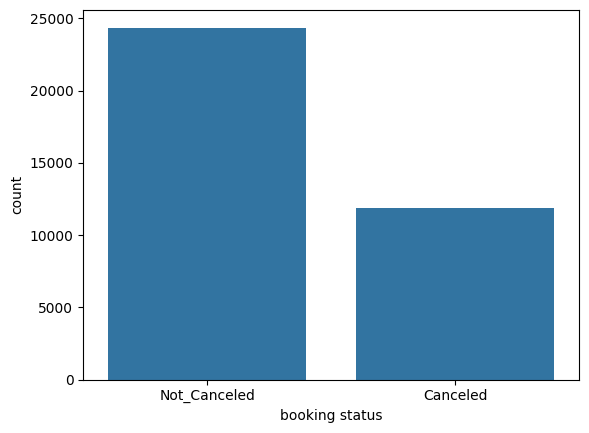

In [24]:
sns.countplot(
    x='booking status',
    data=hotel
)

In [25]:
hotel.info()

<class 'pandas.DataFrame'>
Index: 36246 entries, 1 to 36284
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Booking_ID                36246 non-null  str           
 1   number of adults          36246 non-null  int64         
 2   number of children        36246 non-null  int64         
 3   number of weekend nights  36246 non-null  int64         
 4   number of week nights     36246 non-null  int64         
 5   type of meal              36246 non-null  str           
 6   car parking space         36246 non-null  int64         
 7   room type                 36246 non-null  str           
 8   lead time                 36246 non-null  int64         
 9   market segment type       36246 non-null  str           
 10  repeated                  36246 non-null  int64         
 11  P-C                       36246 non-null  int64         
 12  P-not-C                   36246 no

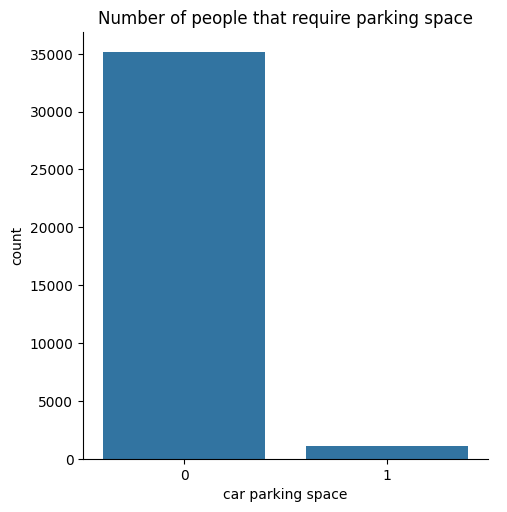

In [26]:
newDf = hotel.groupby("car parking space")["count"].count().reset_index()

sns.catplot(
    x='car parking space',
    y='count',
    data=newDf,
    kind='bar'
)
plt.title("Number of people that require parking space")
plt.show()

In [27]:
hotel['Total Days'] = hotel['number of weekend nights'] + hotel['number of week nights']
hotel.drop(hotel[hotel['Total Days'] == 0].index, inplace=True)
hotel['Average Day Price'] = hotel['average price'] / hotel['Total Days']

In [28]:
hotel

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,...,month,month_name,year,day_name,day,Total People,clean_reservation_date,arrival_date,Total Days,Average Day Price
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,...,11,November,2018,Tuesday,6,1,2018-11-06,2018-11-11,4,26.670000
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,...,2,February,2018,Wednesday,28,3,2018-02-28,2018-03-01,4,12.500000
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,...,5,May,2017,Saturday,20,1,2017-05-20,2017-12-17,2,50.000000
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,...,4,April,2018,Wednesday,11,1,2018-04-11,2018-05-29,3,25.666667
6,INN00007,1,1,1,4,Meal Plan 1,0,Room_Type 1,34,Online,...,10,October,2017,Sunday,15,2,2017-10-15,2017-11-18,5,21.510000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36280,INN36282,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,Online,...,9,September,2018,Thursday,13,2,2018-09-13,2019-08-25,2,57.500000
36281,INN36283,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,Online,...,10,October,2017,Sunday,15,2,2017-10-15,2017-11-18,4,26.887500
36282,INN36284,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,Online,...,12,December,2018,Wednesday,26,2,2018-12-26,2019-03-19,4,26.402500
36283,INN36285,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,Offline,...,7,July,2018,Friday,6,3,2018-07-06,2018-11-04,4,24.225000


<Axes: xlabel='Average Day Price', ylabel='Count'>

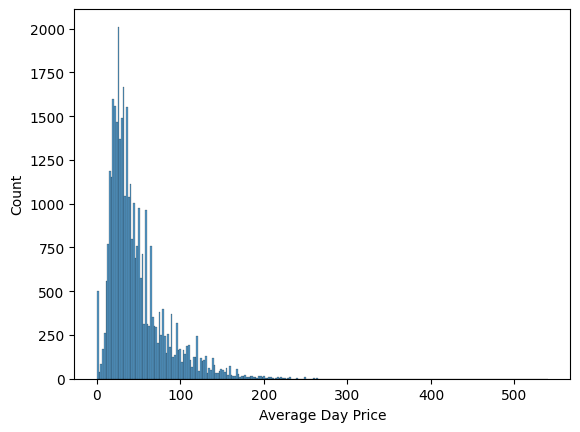

In [29]:
sns.histplot(
    x='Average Day Price',
    data=hotel
)

In [30]:
hotel['Only Adult'] = np.where((hotel['number of adults'] > 0) & (hotel['number of children'] == 0) , 1 , 0 )
hotel['Individual Couple'] = np.where((hotel['number of adults'] > 0) & (hotel['number of children'] == 0) , 1 , 0 )
hotel['Individual Adult'] = np.where(hotel['number of adults'] == 1, 1 , 0 )
hotel['Only Weekend'] = np.where((hotel['number of week nights'] == 0) & (hotel['number of weekend nights'] > 0), 1 , 0 )

In [31]:
hotel['booking status'] = np.where(hotel['booking status'] == 'Canceled', 1 , 0 )

In [32]:
hotel['Only Adult'].value_counts()

Only Adult
1    33476
0     2692
Name: count, dtype: int64

In [33]:
hotel.info()

<class 'pandas.DataFrame'>
Index: 36168 entries, 1 to 36284
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Booking_ID                36168 non-null  str           
 1   number of adults          36168 non-null  int64         
 2   number of children        36168 non-null  int64         
 3   number of weekend nights  36168 non-null  int64         
 4   number of week nights     36168 non-null  int64         
 5   type of meal              36168 non-null  str           
 6   car parking space         36168 non-null  int64         
 7   room type                 36168 non-null  str           
 8   lead time                 36168 non-null  int64         
 9   market segment type       36168 non-null  str           
 10  repeated                  36168 non-null  int64         
 11  P-C                       36168 non-null  int64         
 12  P-not-C                   36168 no

In [34]:
hotel[['Only Adult','number of children','number of adults','number of weekend nights']]

,Only Adult,number of children,number of adults,number of weekend nights
1,1,0,1,1
2,0,1,2,1
3,1,0,1,0
4,1,0,1,1
6,0,1,1,1
...,...,...,...,...
36280,1,0,2,0
36281,1,0,2,1
36282,1,0,2,1
36283,1,0,3,0


In [35]:
hotel.info()

<class 'pandas.DataFrame'>
Index: 36168 entries, 1 to 36284
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Booking_ID                36168 non-null  str           
 1   number of adults          36168 non-null  int64         
 2   number of children        36168 non-null  int64         
 3   number of weekend nights  36168 non-null  int64         
 4   number of week nights     36168 non-null  int64         
 5   type of meal              36168 non-null  str           
 6   car parking space         36168 non-null  int64         
 7   room type                 36168 non-null  str           
 8   lead time                 36168 non-null  int64         
 9   market segment type       36168 non-null  str           
 10  repeated                  36168 non-null  int64         
 11  P-C                       36168 non-null  int64         
 12  P-not-C                   36168 no

In [36]:
hotel = hotel[~np.isinf(hotel['Average Day Price'])]

<Axes: xlabel='lead time', ylabel='Count'>

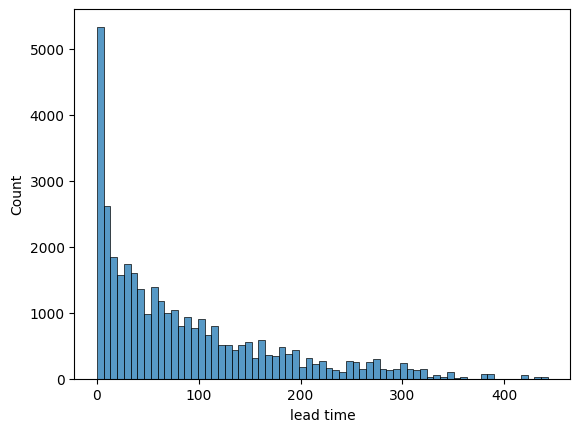

In [37]:
sns.histplot(
    x='lead time',
    data=hotel
)

In [38]:
newDf = hotel[hotel['lead time'] > 300]['booking status'].value_counts().reset_index()
newDf

,booking status,count
0,1,914
1,0,209


In [39]:
# newDf = hotel[hotel['average price'] == None]
# newDf

hotel['average price'] = hotel['average price'].replace(0, np.nan)
hotel['average price'] = hotel['average price'].fillna(
    hotel.groupby(['Total People','room type'])['average price'].transform('median')
)
hotel['Average Day Price'] = hotel['average price'] / hotel['Total Days']
hotel.info()


<class 'pandas.DataFrame'>
Index: 36168 entries, 1 to 36284
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Booking_ID                36168 non-null  str           
 1   number of adults          36168 non-null  int64         
 2   number of children        36168 non-null  int64         
 3   number of weekend nights  36168 non-null  int64         
 4   number of week nights     36168 non-null  int64         
 5   type of meal              36168 non-null  str           
 6   car parking space         36168 non-null  int64         
 7   room type                 36168 non-null  str           
 8   lead time                 36168 non-null  int64         
 9   market segment type       36168 non-null  str           
 10  repeated                  36168 non-null  int64         
 11  P-C                       36168 non-null  int64         
 12  P-not-C                   36168 no

In [40]:
hotel = hotel.drop(columns=['Booking_ID'])

In [41]:
hotel = pd.get_dummies(
    hotel,
    columns=[
        'type of meal',
        'room type',
        'market segment type',
        'month_name',
        'day_name'
    ],
    drop_first=True
)


In [42]:
hotel = hotel.drop(columns=[
    'date of reservation',
    'clean_reservation_date',
    'arrival_date'
])

In [43]:
X = hotel.drop('booking status', axis=1)
y = hotel['booking status']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
def confustionMatrix(y_test,pred):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [46]:
np.isinf(X).sum()

number of adults                     0
number of children                   0
number of weekend nights             0
number of week nights                0
car parking space                    0
lead time                            0
repeated                             0
P-C                                  0
P-not-C                              0
average price                        0
special requests                     0
count                                0
month                                0
year                                 0
day                                  0
Total People                         0
Total Days                           0
Average Day Price                    0
Only Adult                           0
Individual Couple                    0
Individual Adult                     0
Only Weekend                         0
type of meal_Meal Plan 2             0
type of meal_Meal Plan 3             0
type of meal_Not Selected            0
room type_Room_Type 2    

# Logistic Regression

/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWar

{'solver': 'liblinear', 'penalty': 'l1', 'C': 10}
0.8069056590182019
Accuracy: 0.8084047553220901
Precision: 0.7364831953239163
Recall: 0.6414934238438693
F1 Score: 0.6857142857142857


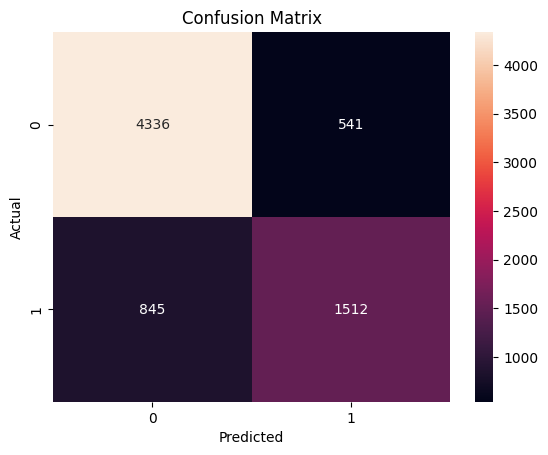

In [50]:
log_reg = LogisticRegression()

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid = RandomizedSearchCV(
    log_reg,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

y_pred = grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

confustionMatrix(y_test,y_pred)

# Random Forest

Random Forest Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}
Random Forest Best CV Score: 0.8965232453325932
Random Forest Accuracy: 0.8972905722974841
Random Forest Precision: 0.8746518105849582
Random Forest Recall: 0.7993211709800594
Random Forest F1 Score: 0.8352915096430946


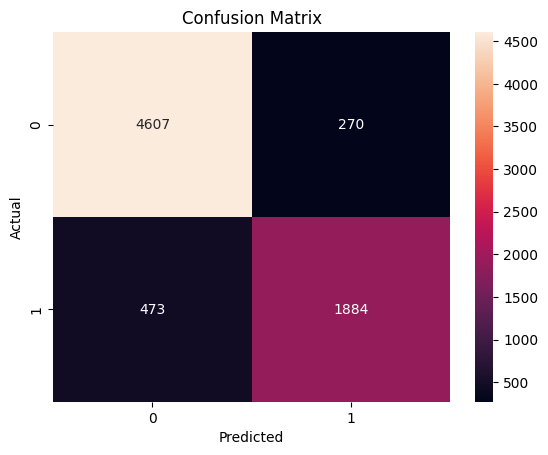

In [53]:
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Randomized Search CV
grid_rf = RandomizedSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Fit model
grid_rf.fit(X_train, y_train)

# Best params and CV score
print("Random Forest Best Params:", grid_rf.best_params_)
print("Random Forest Best CV Score:", grid_rf.best_score_)

# Predictions
y_pred_rf = grid_rf.predict(X_test)

# Metrics
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print("Random Forest F1 Score:", f1_score(y_test, y_pred_rf))

# Confusion matrix
confustionMatrix(y_test,y_pred_rf)

# Banging Classifier 

Gradient Boosting Best Params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10, 'learning_rate': 0.05}
Gradient Boosting Best CV Score: 0.9004978738535202
Gradient Boosting Accuracy: 0.8975670445120265
Gradient Boosting Precision: 0.8686131386861314
Gradient Boosting Recall: 0.8078065337293169
Gradient Boosting F1 Score: 0.8371070564959332


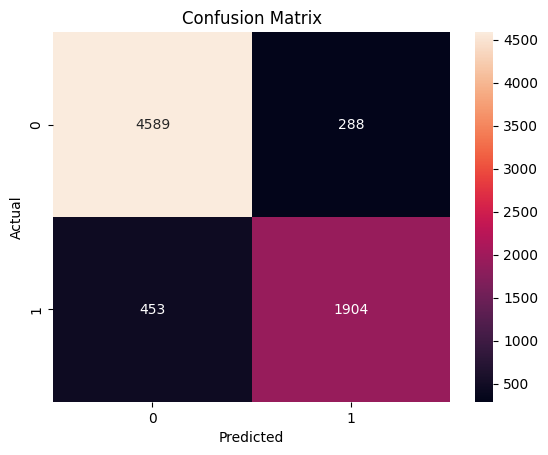

In [52]:

gb = GradientBoostingClassifier(random_state=42)

# Hyperparameter grid
param_grid_gb = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Randomized Search CV
grid_gb = RandomizedSearchCV(
    gb,
    param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Fit model
grid_gb.fit(X_train, y_train)

# Best params and CV score
print("Gradient Boosting Best Params:", grid_gb.best_params_)
print("Gradient Boosting Best CV Score:", grid_gb.best_score_)

# Predictions
y_pred_gb = grid_gb.predict(X_test)

# Metrics
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Precision:", precision_score(y_test, y_pred_gb))
print("Gradient Boosting Recall:", recall_score(y_test, y_pred_gb))
print("Gradient Boosting F1 Score:", f1_score(y_test, y_pred_gb))

# Confusion matrix
confustionMatrix(y_test,y_pred_gb)